In [13]:
pip install torch torchvision tqdm scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [14]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torchvision.models import densenet121
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score



In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data_dir = "/kaggle/input/diabetic-retinopathy-balanced/content/Diabetic_Balanced_Data"
train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "val")
test_dir = os.path.join(data_dir, "test")


In [16]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])


In [17]:
batch_size = 32

train_dataset = ImageFolder(train_dir, transform=transform)
val_dataset = ImageFolder(val_dir, transform=transform)
test_dataset = ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)


In [18]:
model = densenet121(pretrained=True)
model.classifier = nn.Linear(model.classifier.in_features, 5)
model = model.to(device)


In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [20]:
# 1. Train model function with logging
def train_model(model, train_loader, val_loader, epochs=30, patience=5, save_path='best_model.pth'):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0
    patience_counter = 0
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total

        # ✅ Evaluate validation set
        val_loss, val_acc = evaluate(model, val_loader, criterion, return_loss=True)

        scheduler.step(val_loss)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
            print("✅ Saved best model")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("⏹ Early stopping")
                break

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"\nEpoch [{epoch+1}/{epochs}] | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    return history




In [21]:
def evaluate(model, loader, criterion, return_loss=False):
    model.eval()
    correct, total = 0, 0
    total_loss = 0.0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = 100 * correct / total
    avg_loss = total_loss / len(loader)

    if return_loss:
        return avg_loss, acc  # 👈 Now it returns BOTH loss and acc
    else:
        return acc


In [22]:
history = train_model(model, train_loader, val_loader, epochs=30)
# ✅ Evaluate on the test set
test_loss, test_acc = evaluate(model, test_loader, criterion, return_loss=True)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.2f}%")


Epoch 1/30: 100%|██████████| 1088/1088 [06:04<00:00,  2.98it/s]


✅ Saved best model

Epoch [1/30] | Train Acc: 58.06% | Val Acc: 65.87%


Epoch 2/30: 100%|██████████| 1088/1088 [06:09<00:00,  2.95it/s]


✅ Saved best model

Epoch [2/30] | Train Acc: 67.64% | Val Acc: 71.10%


Epoch 3/30: 100%|██████████| 1088/1088 [06:08<00:00,  2.95it/s]


...


Epoch [28/30] | Train Acc: 99.82% | Val Acc: 89.60%


Epoch 29/30: 100%|██████████| 1088/1088 [06:08<00:00,  2.95it/s]



Epoch [29/30] | Train Acc: 99.80% | Val Acc: 89.30%


Epoch 30/30: 100%|██████████| 1088/1088 [06:08<00:00,  2.95it/s]


✅ Saved best model

Epoch [30/30] | Train Acc: 99.86% | Val Acc: 89.82%
Test Loss: 0.4202 | Test Accuracy: 89.60%


In [30]:
test_acc = evaluate(model, test_loader, criterion)
print(f"Test Accuracy: {test_acc:.2f}%")


Test Accuracy: 89.38%


In [31]:
def evaluate_model_metrics(model, loader, class_names):
    model.eval()
    y_true, y_pred, y_probs = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds)
            y_probs.extend(probs)

    print("\n🔍 Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title("📊 Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    try:
        y_true_onehot = np.eye(len(class_names))[y_true]
        auc = roc_auc_score(y_true_onehot, y_probs, multi_class="ovr")
        print(f"🔥 Macro AUC Score: {auc:.4f}")
    except:
        print("⚠ ROC AUC skipped — requires one-hot true labels.")

    return y_true, y_pred, y_probs


/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


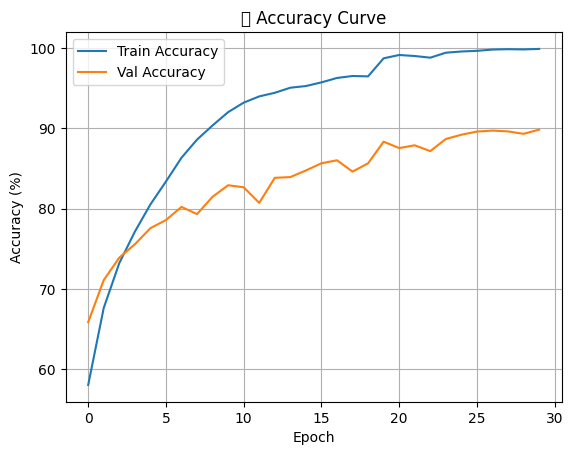

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


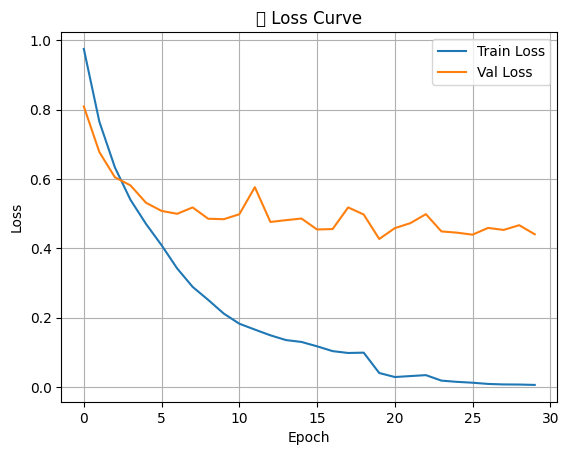

In [32]:
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Val Accuracy')
plt.title('📈 Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()

plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('📉 Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()



🔍 Classification Report:
               precision    recall  f1-score   support

        No DR       0.82      0.78      0.80      1000
         Mild       0.86      0.93      0.90       971
     Moderate       0.84      0.80      0.82      1000
       Severe       0.98      0.99      0.99      1000
Proliferative       0.99      1.00      0.99      1000

     accuracy                           0.90      4971
    macro avg       0.90      0.90      0.90      4971
 weighted avg       0.90      0.90      0.90      4971



/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


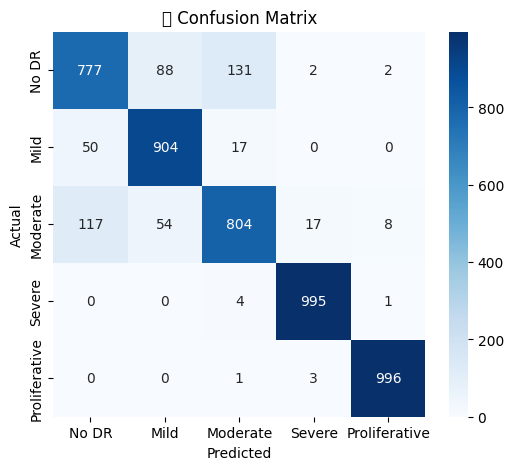

🔥 Macro AUC Score: 0.9850


In [33]:
class_names = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']
y_true, y_pred, y_probs = evaluate_model_metrics(model, test_loader, class_names)


In [34]:
torch.save(model, 'dr_efficientnet_model.pth')  # Save full model
torch.save(model.state_dict(), 'dr_efficientnet_weights.pth')  # Recommended

# Load later
model = torch.load('dr_efficientnet_model.pth')
model.eval()


<ipython-input-34-4563cffbb584>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('dr_efficientnet_model.pth')


DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu